In [0]:
%pip install  sentence-transformers wordcloud textstat


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.8/558.8 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 887.9/888.1 MB 99.2 MB/s eta 0:00:

*** WARNING: max output size exceeded, skipping output. ***

7.3.90-py3-none-manylinux_2_27_x86_64.whl (267.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 31.0 MB/s eta 0:00:00

In [0]:
%restart_python

In [0]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# MLflow for experiment tracking
import mlflow
import mlflow.sklearn
from mlflow import log_metric, log_param, log_artifact

# Statistical analysis
from scipy.stats import chi2_contingency, fisher_exact
from scipy.spatial.distance import cosine
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Text analysis
from sentence_transformers import SentenceTransformer
import re
from collections import Counter
from wordcloud import WordCloud
import textstat

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Data Loading and Initial Setup

username = dbutils.notebook.entry_point.getDbutils().notebook().getContext().userName().get()
class LLMDatasetEvaluator:
    def __init__(self, df, experiment_name=f"/Users/{username}/llm_dataset_evaluation"):
        """
        Initialize the dataset evaluator
        
        Args:
            df (pd.DataFrame): Dataset with columns ['plate_number', 'description', 'language', 'classify', 'category']
            experiment_name (str): MLflow experiment name
        """
        self.df = df.copy()
        self.experiment_name = experiment_name
        self.evaluation_results = {}
        
        # Set up MLflow
        mlflow.set_registry_uri('Databricks')
        mlflow.set_experiment(experiment_name)
        
        # Initialize sentence transformer for semantic analysis
        self.sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
        
        # Validate required columns
        required_cols = ['plate_number', 'description', 'language', 'classify', 'category']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        print(f"Dataset loaded: {len(df)} records")
        print(f"Columns: {list(df.columns)}")
    
    def start_mlflow_run(self, run_name=None):
        """Start MLflow run for tracking metrics"""
        self.mlflow_run = mlflow.start_run(run_name=run_name)
        
        # Log basic dataset info
        log_param("dataset_size", len(self.df))
        log_param("unique_plates", self.df['plate_number'].nunique())
        log_param("languages", list(self.df['language'].unique()))
        
    def end_mlflow_run(self):
        """End MLflow run"""
        mlflow.end_run()

# COMMAND ----------

# Load your dataset (replace with your actual data loading logic)
# Example assuming you have a Delta table or CSV file
#df = spark.table("your_schema.license_plate_dataset").toPandas()
# OR
df = pd.read_csv("Dataset.csv")

# Initialize evaluator
evaluator = LLMDatasetEvaluator(df)
evaluator.start_mlflow_run("dataset_quality_evaluation")



2025/08/07 20:45:10 INFO mlflow.tracking.fluent: Experiment with name '/Users/labuser10979915_1754597785@vocareum.com/llm_dataset_evaluation' does not exist. Creating a new experiment.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dataset loaded: 99 records
Columns: ['plate_number', 'classify', 'category', 'description', 'language', 'Unnamed: 5']


In [0]:
# 2. Basic Data Quality Assessment

def basic_data_quality_check(evaluator):
    """Perform basic data quality checks"""
    df = evaluator.df
    
    print("=== BASIC DATA QUALITY ASSESSMENT ===\n")
    
    # Missing data analysis
    print("1. Missing Data Analysis:")
    missing_stats = df.isnull().sum()
    missing_pct = (missing_stats / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing_Count': missing_stats,
        'Missing_Percentage': missing_pct
    })
    print(missing_df[missing_df['Missing_Count'] > 0])
    
    # Log missing data metrics
    for col in missing_df.index:
        log_metric(f"missing_data_{col}_pct", missing_df.loc[col, 'Missing_Percentage'])
    
    # Data type analysis
    print("\n2. Data Types:")
    print(df.dtypes)
    
    # Unique value counts
    print("\n3. Unique Value Counts:")
    for col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
    
    # Basic statistics for text fields
    print("\n4. Description Length Statistics:")
    df['description_length'] = df['description'].str.len()
    desc_stats = df['description_length'].describe()
    display(desc_stats)
    
    # Log description length metrics
    log_metric("avg_description_length", desc_stats['mean'])
    log_metric("median_description_length", desc_stats['50%'])
    log_metric("max_description_length", desc_stats['max'])
    
    # Check for duplicates
    print(f"\n5. Duplicate Records: {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.2f}%)")
    duplicate_plates = df['plate_number'].duplicated().sum()
    print(f"   Duplicate Plate Numbers: {duplicate_plates} ({duplicate_plates/len(df)*100:.2f}%)")
    
    log_metric("duplicate_records_pct", df.duplicated().sum()/len(df)*100)
    log_metric("duplicate_plates_pct", duplicate_plates/len(df)*100)
    
    return df

df_with_stats = basic_data_quality_check(evaluator)


=== BASIC DATA QUALITY ASSESSMENT ===

1. Missing Data Analysis:
             Missing_Count  Missing_Percentage
category                25               25.25
description             25               25.25

2. Data Types:
plate_number    object
classify        object
category        object
description     object
language        object
Unnamed: 5      object
dtype: object

3. Unique Value Counts:
plate_number: 99 unique values
classify: 2 unique values
category: 7 unique values
description: 74 unique values
language: 15 unique values
Unnamed: 5: 4 unique values

4. Description Length Statistics:


count     74.000000
mean     115.797297
std       25.235863
min       29.000000
25%      106.000000
50%      122.000000
75%      130.750000
max      150.000000
Name: description_length, dtype: float64


5. Duplicate Records: 0 (0.00%)
   Duplicate Plate Numbers: 0 (0.00%)


=== CLASS DISTRIBUTION ANALYSIS ===

1. Primary Classification Distribution:
   Reject: 74 (74.75%)
   Approve: 25 (25.25%)

2. Rejection Category Distribution (74 rejected items):
   Category A: 16 (21.62%)
   Category F: 15 (20.27%)
   Category C: 14 (18.92%)
   Category B: 9 (12.16%)
   Category G: 8 (10.81%)
   Category E: 7 (9.46%)
   Category D: 5 (6.76%)

3. Language Distribution:
   English: 63 (63.64%)
   Punjabi: 7 (7.07%)
   Arabic: 6 (6.06%)
   Hindi: 6 (6.06%)
   Chinese: 3 (3.03%)
   Hindi/Urdu: 3 (3.03%)
   Punjabi/Hindi: 2 (2.02%)
   German: 2 (2.02%)
   Hindi/Sanskrit: 1 (1.01%)
   Persian: 1 (1.01%)
   Malay: 1 (1.01%)
   Greek: 1 (1.01%)
   Spanish: 1 (1.01%)
   Turkic: 1 (1.01%)
   Italian: 1 (1.01%)


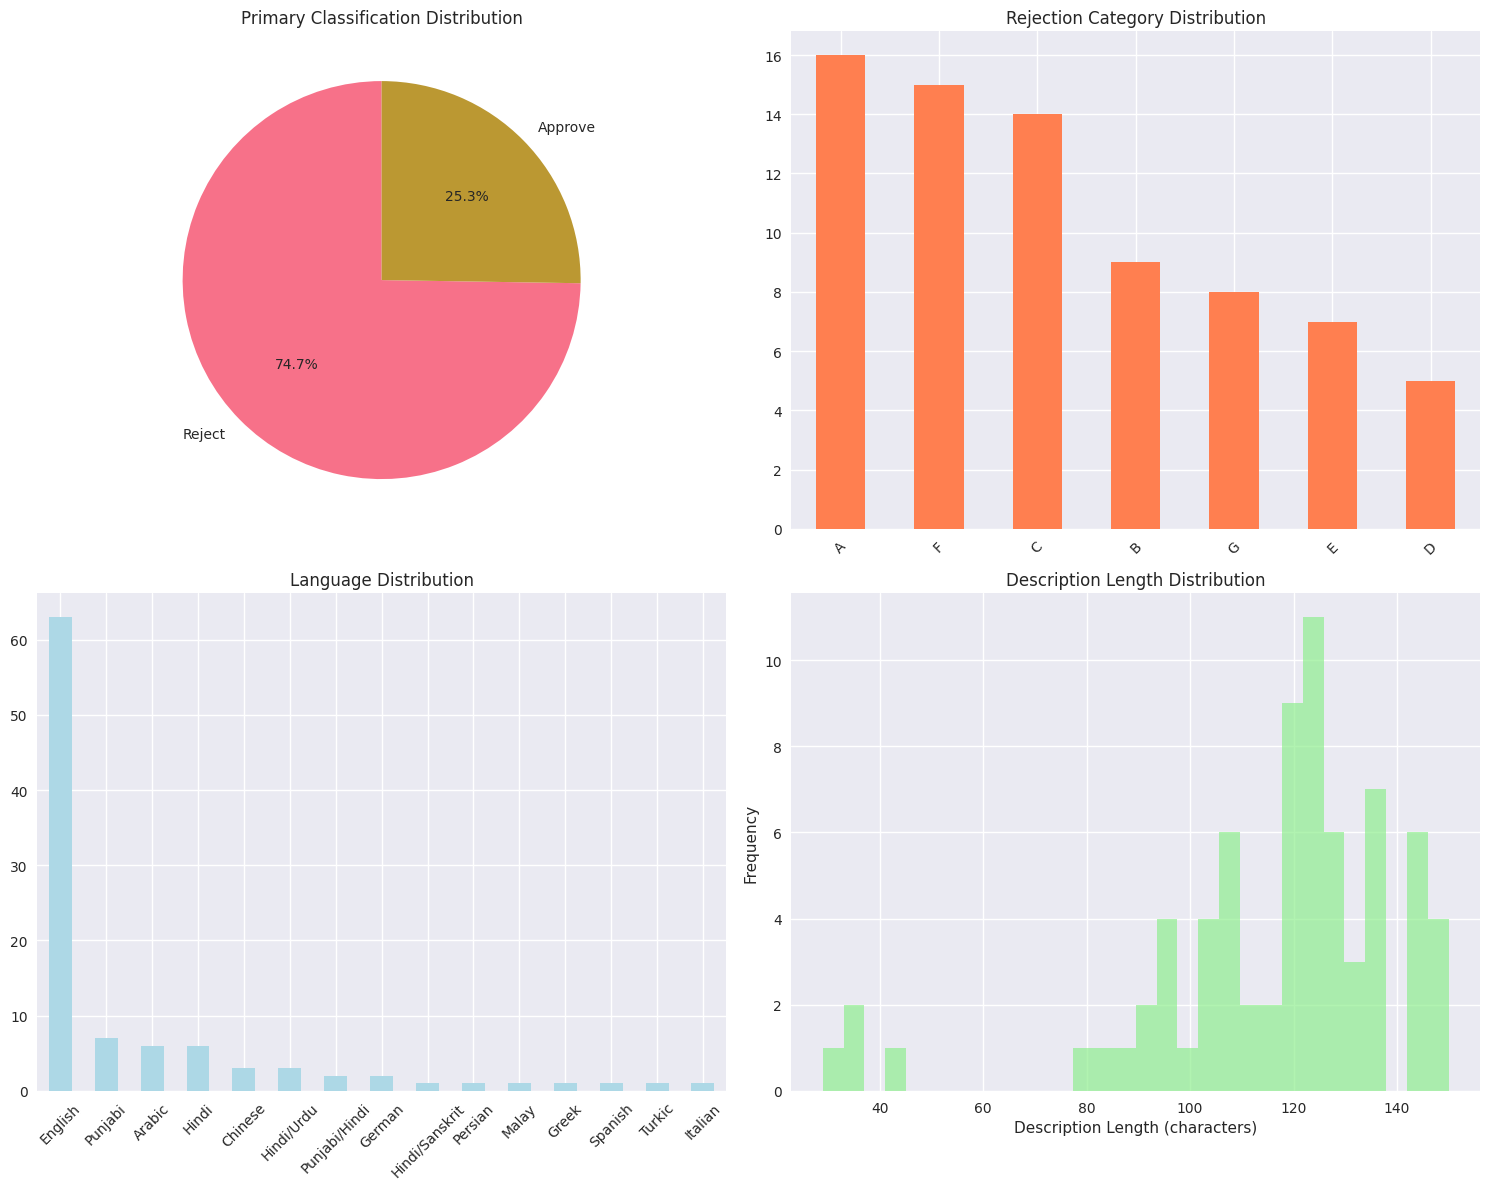

In [0]:
# 3. Class Distribution and Balance Analysis

def analyze_class_distribution(evaluator):
    """Analyze class distribution and balance"""
    df = evaluator.df
    
    print("=== CLASS DISTRIBUTION ANALYSIS ===\n")
    
    # 1. Primary classification distribution
    classify_dist = df['classify'].value_counts()
    classify_pct = df['classify'].value_counts(normalize=True) * 100
    
    print("1. Primary Classification Distribution:")
    for class_name in classify_dist.index:
        count = classify_dist[class_name]
        pct = classify_pct[class_name]
        print(f"   {class_name}: {count} ({pct:.2f}%)")
        log_metric(f"class_distribution_{class_name.lower()}_pct", pct)
    
    # 2. Category distribution (for rejected items)
    rejected_df = df[df['classify'].str.lower() == 'reject']
    if len(rejected_df) > 0:
        print(f"\n2. Rejection Category Distribution ({len(rejected_df)} rejected items):")
        category_dist = rejected_df['category'].value_counts()
        category_pct = rejected_df['category'].value_counts(normalize=True) * 100
        
        for category in category_dist.index:
            count = category_dist[category]
            pct = category_pct[category]
            print(f"   Category {category}: {count} ({pct:.2f}%)")
            log_metric(f"rejection_category_{category}_pct", pct)
    
    # 3. Language distribution
    print(f"\n3. Language Distribution:")
    lang_dist = df['language'].value_counts()
    lang_pct = df['language'].value_counts(normalize=True) * 100
    
    for lang in lang_dist.index:
        count = lang_dist[lang]
        pct = lang_pct[lang]
        print(f"   {lang}: {count} ({pct:.2f}%)")
        log_metric(f"language_distribution_{lang.lower()}_pct", pct)
    
    # 4. Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Classification pie chart
    classify_dist.plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%', startangle=90)
    axes[0,0].set_title('Primary Classification Distribution')
    axes[0,0].set_ylabel('')
    
    # Category bar chart (if rejections exist)
    if len(rejected_df) > 0:
        category_dist.plot(kind='bar', ax=axes[0,1], color='coral')
        axes[0,1].set_title('Rejection Category Distribution')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # Language distribution
    lang_dist.plot(kind='bar', ax=axes[1,0], color='lightblue')
    axes[1,0].set_title('Language Distribution')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Description length distribution
    df['description_length'].hist(ax=axes[1,1], bins=30, color='lightgreen', alpha=0.7)
    axes[1,1].set_title('Description Length Distribution')
    axes[1,1].set_xlabel('Description Length (characters)')
    axes[1,1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig('/tmp/class_distribution_analysis.png', dpi=300, bbox_inches='tight')
    log_artifact('/tmp/class_distribution_analysis.png')
    plt.show()
    
    return classify_dist, category_dist if len(rejected_df) > 0 else None, lang_dist

classify_dist, category_dist, lang_dist = analyze_class_distribution(evaluator)

=== COMPREHENSIVE BIAS AND FAIRNESS ANALYSIS ===

1. Classification Rate by Language (%):
classify        Approve  Reject
language                       
Arabic             0.00  100.00
Chinese           33.33   66.67
English           31.75   68.25
German             0.00  100.00
Greek              0.00  100.00
Hindi              0.00  100.00
Hindi/Sanskrit     0.00  100.00
Hindi/Urdu         0.00  100.00
Italian            0.00  100.00
Malay              0.00  100.00
Persian            0.00  100.00
Punjabi           57.14   42.86
Punjabi/Hindi      0.00  100.00
Spanish            0.00  100.00
Turkic             0.00  100.00

2. Demographic Bias Assessment:
   English: 20/63 approved (0.317 rate)
   Arabic: 0/6 approved (0.000 rate)
   Hindi: 0/6 approved (0.000 rate)
   Hindi/Sanskrit: 0/1 approved (0.000 rate)
   Punjabi: 4/7 approved (0.571 rate)
   Chinese: 1/3 approved (0.333 rate)
   Persian: 0/1 approved (0.000 rate)
   Malay: 0/1 approved (0.000 rate)
   Greek: 0/1 approved (0

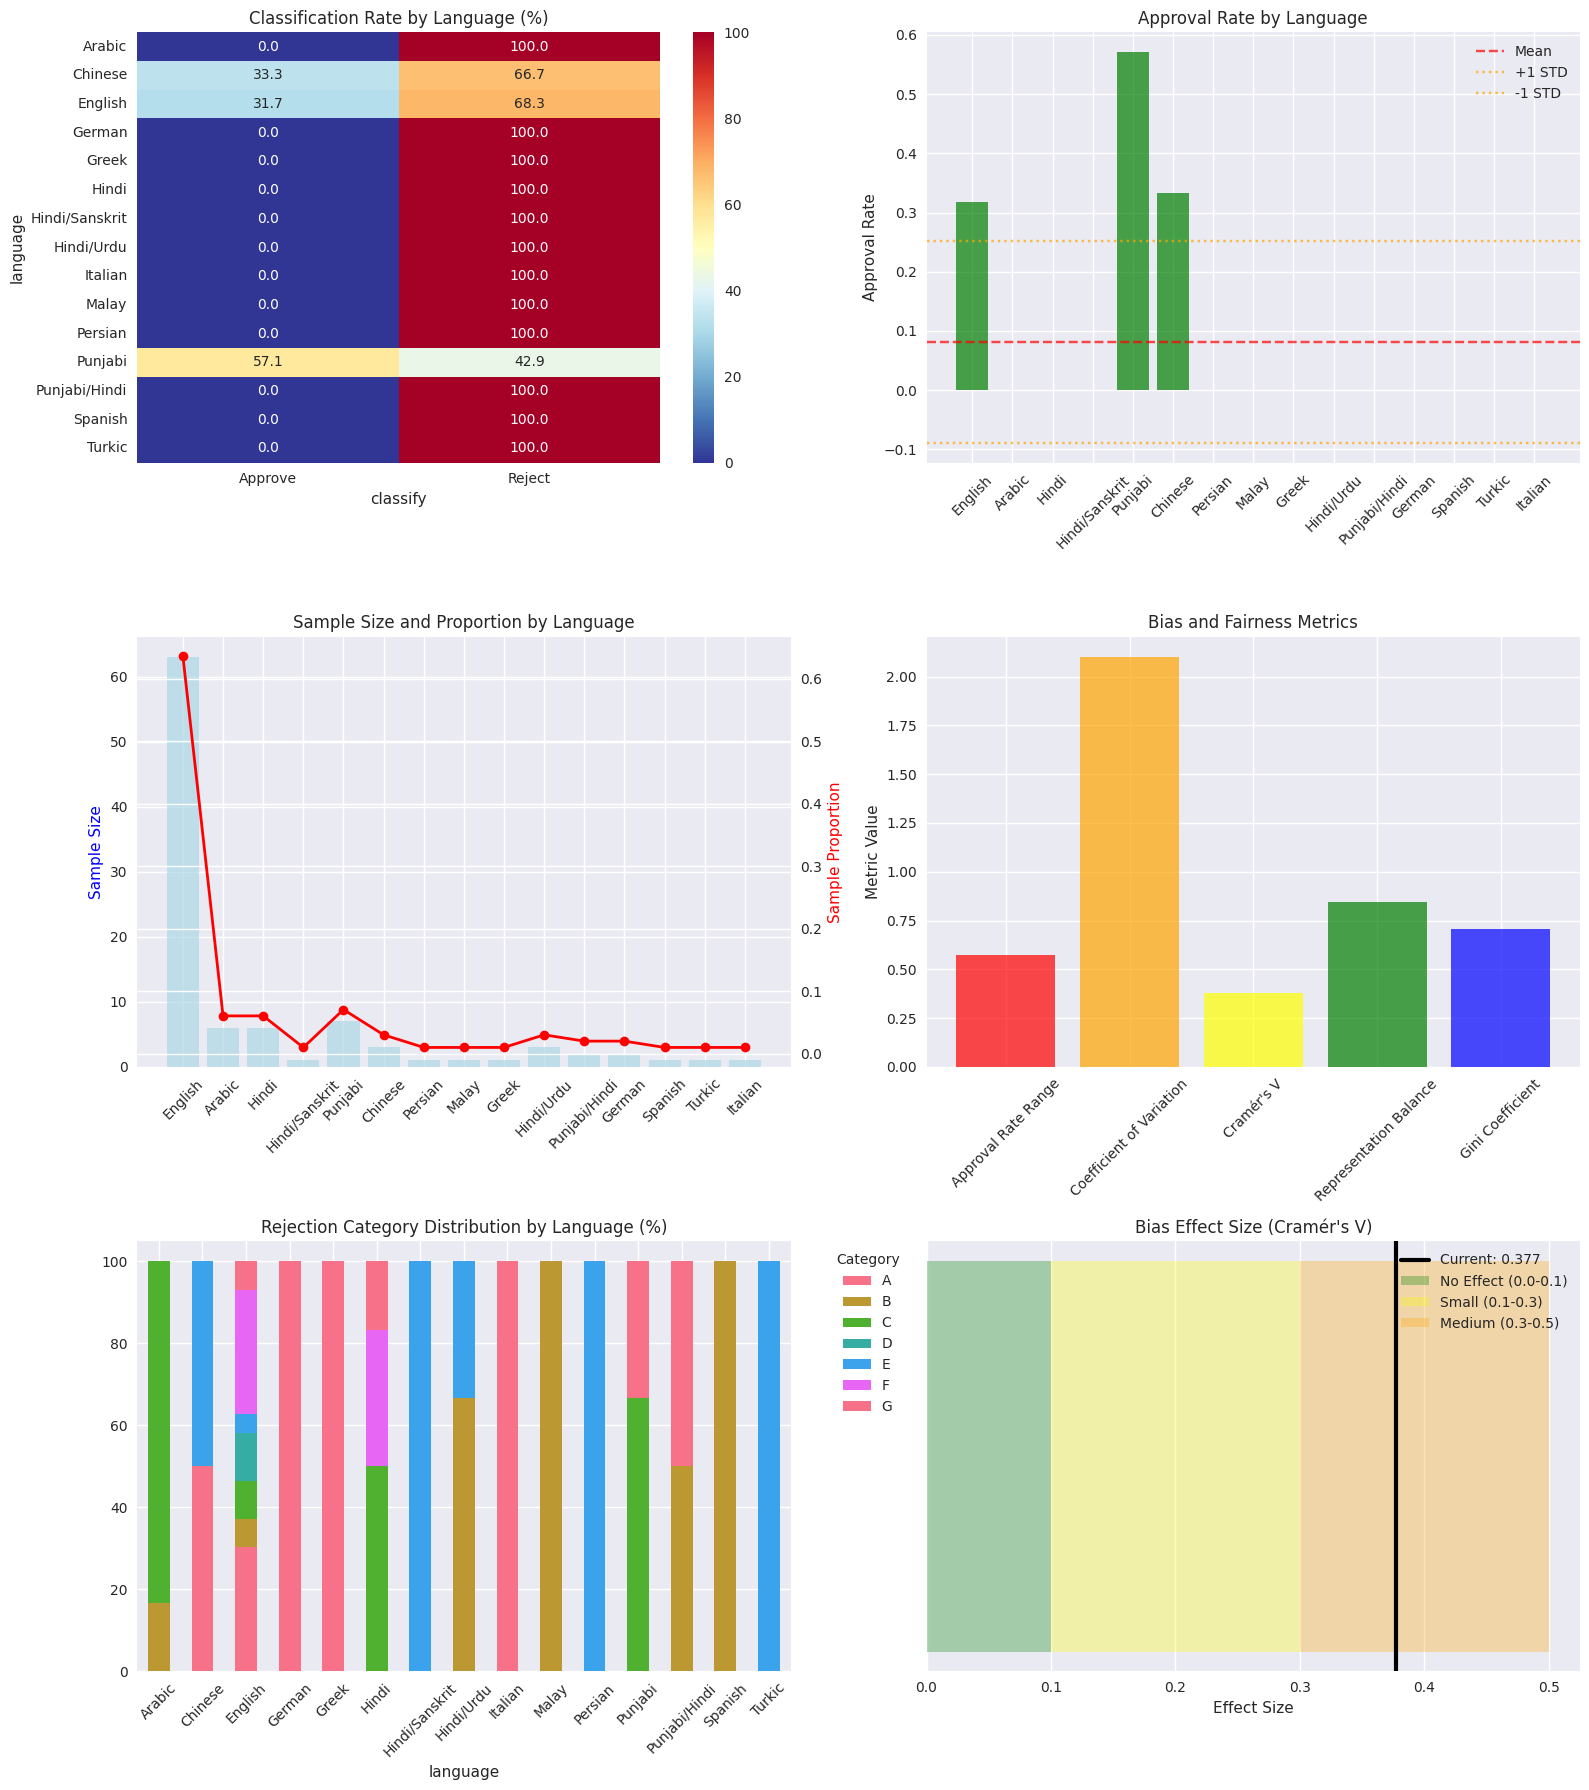

In [0]:
# 4. Language Bias Analysis


def analyze_language_bias(evaluator):
    """Comprehensive demographic bias analysis with advanced fairness metrics"""
    df = evaluator.df
    
    print("=== COMPREHENSIVE BIAS AND FAIRNESS ANALYSIS ===\n")
    
    # 1. Basic Classification Rate Analysis
    lang_class_crosstab = pd.crosstab(df['language'], df['classify'], normalize='index') * 100
    
    print("1. Classification Rate by Language (%):")
    print(lang_class_crosstab.round(2))
    
    # 2. Enhanced Demographic Bias Evaluation
    print(f"\n2. Demographic Bias Assessment:")
    
    # Group statistics for each language
    group_stats = {}
    total_records = len(df)
    
    for language in df['language'].dropna().unique():
        lang_data = df[df['language'] == language]
        total_group = len(lang_data)
        
        # Handle different possible approval labels
        approved_group = len(lang_data[lang_data['classify'].str.lower().isin(['approve', 'approved'])])
        
        group_stats[language] = {
            'total': total_group,
            'approved': approved_group,
            'rejected': total_group - approved_group,
            'approval_rate': approved_group / total_group if total_group > 0 else 0,
            'sample_proportion': total_group / total_records
        }
        
        print(f"   {language}: {approved_group}/{total_group} approved ({group_stats[language]['approval_rate']:.3f} rate)")
    
    # 3. Advanced Bias Metrics
    approval_rates = [stats['approval_rate'] for stats in group_stats.values()]
    sample_proportions = [stats['sample_proportion'] for stats in group_stats.values()]
    
    approval_rate_mean = np.mean(approval_rates)
    approval_rate_std = np.std(approval_rates)
    approval_rate_range = max(approval_rates) - min(approval_rates)
    approval_rate_cv = approval_rate_std / approval_rate_mean if approval_rate_mean > 0 else 0
    
    print(f"\n3. Fairness Metrics:")
    print(f"   Approval Rate Range: {approval_rate_range:.3f}")
    print(f"   Approval Rate CV: {approval_rate_cv:.3f}")
    print(f"   Demographic Parity Violation: {approval_rate_range:.3f}")
    
    # 4. Statistical Tests
    contingency_table = pd.crosstab(df['language'], df['classify'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Effect size (Cramér's V)
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    
    print(f"\n4. Statistical Tests:")
    print(f"   Chi-square statistic: {chi2:.4f}")
    print(f"   P-value: {p_value:.6f}")
    print(f"   Cramér's V (effect size): {cramers_v:.3f}")
    print(f"   Degrees of freedom: {dof}")
    
    bias_significant = p_value < 0.05
    print(f"   Significant bias detected: {'Yes' if bias_significant else 'No'} (α=0.05)")
    
    # 5. Representation Balance
    representation_balance = 1 - np.std(sample_proportions)
    
    print(f"\n5. Representation Analysis:")
    print(f"   Representation Balance: {representation_balance:.3f}")
    
    # 6. Gini Coefficient for Inequality
    gini_coefficient = calculate_gini_coefficient(sample_proportions)
    print(f"   Sample Distribution Gini: {gini_coefficient:.3f}")
    
    # Log enhanced bias metrics
    log_metric("language_bias_chi2", chi2)
    log_metric("language_bias_p_value", p_value)
    log_metric("language_bias_detected", int(bias_significant))
    log_metric("cramers_v_effect_size", cramers_v)
    log_metric("approval_rate_range", approval_rate_range)
    log_metric("approval_rate_cv", approval_rate_cv)
    log_metric("demographic_parity_violation", approval_rate_range)
    log_metric("representation_balance", representation_balance)
    log_metric("sample_distribution_gini", gini_coefficient)
    
    # 7. Intersectional Bias Analysis
    print(f"\n6. Intersectional Bias Analysis:")
    
    # Create intersection groups (language + classification)
    df_temp = df.copy()
    df_temp['intersection'] = df_temp['language'].astype(str) + '_' + df_temp['classify'].astype(str)
    
    intersection_stats = {}
    for group in df_temp['intersection'].unique():
        group_count = len(df_temp[df_temp['intersection'] == group])
        intersection_stats[group] = {
            'count': group_count,
            'proportion': group_count / total_records
        }
    
    # Intersection inequality metrics
    intersection_proportions = [stats['proportion'] for stats in intersection_stats.values()]
    intersection_gini = calculate_gini_coefficient(intersection_proportions)
    intersection_entropy = calculate_entropy(intersection_proportions)
    
    print(f"   Intersection Groups: {len(intersection_stats)}")
    print(f"   Intersection Gini: {intersection_gini:.3f}")
    print(f"   Intersection Entropy: {intersection_entropy:.3f}")
    
    log_metric("intersection_gini_coefficient", intersection_gini)
    log_metric("intersection_entropy", intersection_entropy)
    
    # Category bias by language (for rejected items)
    rejected_df = df[df['classify'].str.lower().isin(['reject', 'rejected'])]
    if len(rejected_df) > 0:
        print(f"\n7. Rejection Category Distribution by Language:")
        lang_category_crosstab = pd.crosstab(rejected_df['language'], rejected_df['category'], normalize='index') * 100
        print(lang_category_crosstab.round(2))
    
    # Visualization with enhanced metrics
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    
    # Heatmap of classification by language
    sns.heatmap(lang_class_crosstab, annot=True, fmt='.1f', cmap='RdYlBu_r', ax=axes[0,0])
    axes[0,0].set_title('Classification Rate by Language (%)')
    
    # Bar plot of approval rates by language
    approval_rates_plot = [group_stats[lang]['approval_rate'] for lang in group_stats.keys()]
    languages = list(group_stats.keys())
    
    bars = axes[0,1].bar(languages, approval_rates_plot, color='green', alpha=0.7)
    axes[0,1].set_title('Approval Rate by Language')
    axes[0,1].set_ylabel('Approval Rate')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Add fairness threshold lines
    axes[0,1].axhline(y=approval_rate_mean, color='red', linestyle='--', alpha=0.7, label='Mean')
    axes[0,1].axhline(y=approval_rate_mean + approval_rate_std, color='orange', linestyle=':', alpha=0.7, label='+1 STD')
    axes[0,1].axhline(y=approval_rate_mean - approval_rate_std, color='orange', linestyle=':', alpha=0.7, label='-1 STD')
    axes[0,1].legend()
    
    # Sample size by language with proportion overlay
    sample_sizes = [group_stats[lang]['total'] for lang in languages]
    sample_props = [group_stats[lang]['sample_proportion'] for lang in languages]
    
    ax1 = axes[1,0]
    bars1 = ax1.bar(languages, sample_sizes, color='lightblue', alpha=0.7, label='Sample Size')
    ax1.set_title('Sample Size and Proportion by Language')
    ax1.set_ylabel('Sample Size', color='blue')
    ax1.tick_params(axis='x', rotation=45)
    
    ax2 = ax1.twinx()
    ax2.plot(languages, sample_props, color='red', marker='o', linewidth=2, label='Proportion')
    ax2.set_ylabel('Sample Proportion', color='red')
    
    # Bias metrics radar chart equivalent (bar chart)
    bias_metrics = {
        'Approval Rate Range': approval_rate_range,
        'Coefficient of Variation': approval_rate_cv,
        'Cramér\'s V': cramers_v,
        'Representation Balance': representation_balance,
        'Gini Coefficient': gini_coefficient
    }
    
    axes[1,1].bar(list(bias_metrics.keys()), list(bias_metrics.values()), 
                 color=['red', 'orange', 'yellow', 'green', 'blue'], alpha=0.7)
    axes[1,1].set_title('Bias and Fairness Metrics')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].set_ylabel('Metric Value')
    
    # Category distribution by language (if rejections exist)
    if len(rejected_df) > 0:
        lang_category_crosstab.plot(kind='bar', stacked=True, ax=axes[2,0])
        axes[2,0].set_title('Rejection Category Distribution by Language (%)')
        axes[2,0].tick_params(axis='x', rotation=45)
        axes[2,0].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Effect size visualization
    effect_size_labels = ['No Effect', 'Small', 'Medium', 'Large']
    effect_size_thresholds = [0, 0.1, 0.3, 0.5]
    current_effect = cramers_v
    
    colors = ['green', 'yellow', 'orange', 'red']
    for i, (label, threshold) in enumerate(zip(effect_size_labels, effect_size_thresholds)):
        if i < len(effect_size_thresholds) - 1:
            width = effect_size_thresholds[i+1] - threshold
            axes[2,1].barh(0, width, left=threshold, color=colors[i], alpha=0.3, 
                          label=f'{label} ({threshold:.1f}-{effect_size_thresholds[i+1]:.1f})')
    
    axes[2,1].axvline(x=current_effect, color='black', linewidth=3, label=f'Current: {current_effect:.3f}')
    axes[2,1].set_title('Bias Effect Size (Cramér\'s V)')
    axes[2,1].set_xlabel('Effect Size')
    axes[2,1].legend()
    axes[2,1].set_yticks([])
    
    plt.tight_layout()
    plt.savefig('/tmp/enhanced_language_bias_analysis.png', dpi=300, bbox_inches='tight')
    log_artifact('/tmp/enhanced_language_bias_analysis.png')
    plt.show()
    
    return lang_class_crosstab, bias_significant, group_stats, bias_metrics

def calculate_gini_coefficient(values):
    """Calculate Gini coefficient for inequality measurement"""
    values = np.array(values)
    if len(values) == 0 or np.sum(values) == 0:
        return 0
    
    values = np.sort(values)
    n = len(values)
    cumsum = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

def calculate_entropy(probabilities):
    """Calculate Shannon entropy for distribution analysis"""
    probabilities = np.array(probabilities)
    probabilities = probabilities[probabilities > 0]  # Remove zero probabilities
    if len(probabilities) <= 1:
        return 0
    return -np.sum(probabilities * np.log2(probabilities))

# Execute enhanced bias analysis
lang_class_crosstab, bias_detected, group_stats, bias_metrics = analyze_language_bias(evaluator)


In [0]:

# 5. Category Consistency Analysis

def analyze_category_consistency(evaluator):
    """Analyze consistency in category assignments"""
    df = evaluator.df
    rejected_df = df[df['classify'].str.lower() == 'reject'].copy()
    
    if len(rejected_df) == 0:
        print("No rejected samples found for category consistency analysis")
        return None
    
    print("=== CATEGORY CONSISTENCY ANALYSIS ===\n")
    
    # Generate embeddings for descriptions
    print("Generating semantic embeddings for descriptions...")
    descriptions = rejected_df['description'].fillna('').tolist()
    embeddings = evaluator.sentence_model.encode(descriptions)
    
    # Analyze semantic similarity within categories
    print("1. Intra-Category Semantic Similarity:")
    category_similarities = {}
    
    for category in rejected_df['category'].unique():
        if pd.isna(category):
            continue
            
        category_mask = rejected_df['category'] == category
        category_embeddings = embeddings[category_mask]
        
        if len(category_embeddings) > 1:
            # Calculate pairwise similarities
            similarity_matrix = cosine_similarity(category_embeddings)
            # Get upper triangular part (excluding diagonal)
            upper_tri = np.triu(similarity_matrix, k=1)
            similarities = upper_tri[upper_tri > 0]
            
            avg_similarity = similarities.mean()
            category_similarities[category] = avg_similarity
            
            print(f"   Category {category}: {avg_similarity:.3f} (n={len(category_embeddings)})")
            log_metric(f"category_{category}_avg_similarity", avg_similarity)
        else:
            print(f"   Category {category}: Only 1 sample - cannot calculate similarity")
    
    # Find potential misclassified items using clustering
    print(f"\n2. Potential Category Inconsistencies:")
    
    # Perform clustering analysis
    n_clusters = min(len(rejected_df['category'].unique()), 10)  # Don't exceed available categories
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    
    rejected_df['cluster'] = cluster_labels
    
    # Analyze cluster-category alignment
    inconsistencies = []
    for cluster_id in range(n_clusters):
        cluster_mask = rejected_df['cluster'] == cluster_id
        cluster_categories = rejected_df[cluster_mask]['category'].value_counts()
        
        if len(cluster_categories) > 1:  # Mixed categories in cluster
            dominant_category = cluster_categories.index[0]
            minority_items = rejected_df[cluster_mask & (rejected_df['category'] != dominant_category)]
            
            for idx, row in minority_items.iterrows():
                inconsistencies.append({
                    'plate_number': row['plate_number'],
                    'description': row['description'],
                    'assigned_category': row['category'],
                    'cluster_dominant_category': dominant_category,
                    'cluster_id': cluster_id
                })
    
    print(f"   Found {len(inconsistencies)} potential inconsistencies")
    log_metric("potential_inconsistencies_count", len(inconsistencies))
    
    # Display top inconsistencies
    if inconsistencies:
        inconsistencies_df = pd.DataFrame(inconsistencies)
        print(f"\n   Top 5 Potential Inconsistencies:")
        for i, row in inconsistencies_df.head().iterrows():
            print(f"   - Plate: {row['plate_number']}")
            print(f"     Description: {row['description'][:100]}...")
            print(f"     Assigned: {row['assigned_category']}, Cluster suggests: {row['cluster_dominant_category']}")
            print()
    
    # Visualization
    if len(embeddings) > 1:
        # Use t-SNE for dimensionality reduction
        print("Creating t-SNE visualization...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
        embeddings_2d = tsne.fit_transform(embeddings)
        
        # Create interactive plot
        fig = go.Figure()
        
        colors = px.colors.qualitative.Set1
        for i, category in enumerate(rejected_df['category'].unique()):
            if pd.isna(category):
                continue
            mask = rejected_df['category'] == category
            fig.add_trace(go.Scatter(
                x=embeddings_2d[mask, 0],
                y=embeddings_2d[mask, 1],
                mode='markers',
                name=f'Category {category}',
                marker=dict(color=colors[i % len(colors)]),
                text=[f"Plate: {p}<br>Cat: {c}<br>Desc: {d[:50]}..." 
                      for p, c, d in zip(rejected_df[mask]['plate_number'], 
                                        rejected_df[mask]['category'],
                                        rejected_df[mask]['description'])],
                hovertemplate='%{text}<extra></extra>'
            ))
        
        fig.update_layout(
            title='Semantic Clustering of Rejection Descriptions by Category',
            xaxis_title='t-SNE Component 1',
            yaxis_title='t-SNE Component 2',
            width=800,
            height=600
        )
        
        fig.write_html('/tmp/category_consistency_plot.html')
        log_artifact('/tmp/category_consistency_plot.html')
        fig.show()
    
    return category_similarities, inconsistencies

category_similarities, inconsistencies = analyze_category_consistency(evaluator)

=== CATEGORY CONSISTENCY ANALYSIS ===

Generating semantic embeddings for descriptions...
1. Intra-Category Semantic Similarity:
   Category C: 0.354 (n=14)
   Category F: 0.353 (n=15)
   Category G: 0.334 (n=8)
   Category E: 0.351 (n=7)
   Category B: 0.370 (n=9)
   Category A: 0.374 (n=16)
   Category D: 0.368 (n=5)


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f9081d6ede0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'
Ex


2. Potential Category Inconsistencies:


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f907f1d34c0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/databricks/python/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'split'


   Found 41 potential inconsistencies

   Top 5 Potential Inconsistencies:
   - Plate: SAIIMA
     Description: "The plate SAIIMA is the transliteration of an Arabic word meaning fasting woman, a term with direct...
     Assigned: C, Cluster suggests: G

   - Plate: 7.hryana
     Description: "The plate refers to Haryana, an Indian state, which is considered a political and geographical refe...
     Assigned: E, Cluster suggests: G

   - Plate: gbishnoi
     Description: Bishnoi is community in India...
     Assigned: C, Cluster suggests: G

   - Plate: SINHMAR1
     Description: "The plate can be read as Singh Mar, which translates from Hindi/Punjabi to kill/hit Singh, a direct...
     Assigned: F, Cluster suggests: G

   - Plate: taaj.s
     Description: "Taaj is the word for crown in Hindi/Urdu, a title associated with royalty and dignitaries, making i...
     Assigned: E, Cluster suggests: G

Creating t-SNE visualization...


In [0]:
# MAGIC ## 6. Outlier and Error Detection

def detect_outliers_and_errors(evaluator):
    """Detect potential outliers and labeling errors"""
    df = evaluator.df
    
    print("=== OUTLIER AND ERROR DETECTION ===\n")
    
    # 1. Text-based anomaly detection
    print("1. Text-based Anomaly Detection:")
    
    # Extremely short descriptions
    short_desc_threshold = 10
    short_descriptions = df[df['description'].str.len() < short_desc_threshold]
    print(f"   Extremely short descriptions (<{short_desc_threshold} chars): {len(short_descriptions)}")
    
    if len(short_descriptions) > 0:
        print("   Examples:")
        for idx, row in short_descriptions.head(3).iterrows():
            print(f"     - '{row['description']}' -> {row['classify']} ({row['category']})")
    
    # Extremely long descriptions
    long_desc_threshold = df['description'].str.len().quantile(0.95)
    long_descriptions = df[df['description'].str.len() > long_desc_threshold]
    print(f"   Extremely long descriptions (>{long_desc_threshold:.0f} chars): {len(long_descriptions)}")
    
    # 2. Language inconsistency detection
    print(f"\n2. Language Inconsistency Detection:")
    
    # Simple heuristics for language detection
    def detect_language_hints(text):
        if pd.isna(text):
            return "unknown"
        text_lower = text.lower()
        
        # Urdu/Arabic scripts (simple heuristic)
        if any(ord(char) > 1536 and ord(char) < 1791 for char in text):
            return "arabic_script"
        # English letters
        elif any(char.isalpha() and ord(char) < 128 for char in text):
            return "english"
        else:
            return "mixed_or_other"
    
    df['detected_language'] = df['description'].apply(detect_language_hints)
    language_mismatches = df[df['language'].str.lower() != df['detected_language']]
    display(language_mismatches)
    print(f"   Potential language mismatches: {len(language_mismatches)}")
    if len(language_mismatches) > 0:
        print("   Examples:")
        for idx, row in language_mismatches.head(3).iterrows():
            print(f"     - Labeled: {row['language']}, Detected: {row['detected_language']}")
            print(f"       Text: '{str(row['description'])[:50]}...'")

    # 3. Suspicious approval patterns
    print(f"\n3. Suspicious Approval Patterns:")
    
    # Approved items with suspicious keywords
    suspicious_keywords = ['reject', 'invalid', 'error', 'wrong', 'bad', 'inappropriate']
    approved_df = df[df['classify'].str.lower() == 'approve']
    
    suspicious_approvals = []
    for keyword in suspicious_keywords:
        matches = approved_df[approved_df['description'].str.lower().str.contains(keyword, na=False)]
        suspicious_approvals.extend(matches.index.tolist())
    
    suspicious_approvals = list(set(suspicious_approvals))
    print(f"   Approved items with suspicious keywords: {len(suspicious_approvals)}")
    
    if len(suspicious_approvals) > 0:
        print("   Examples:")
        for idx in suspicious_approvals[:3]:
            row = df.loc[idx]
            print(f"     - '{row['description'][:100]}...' -> {row['classify']}")
    
    # 4. Rejected items without categories
    print(f"\n4. Data Integrity Issues:")
    rejected_no_category = df[(df['classify'].str.lower() == 'reject') & (df['category'].isna())]
    print(f"   Rejected items without category: {len(rejected_no_category)}")
    
    approved_with_category = df[(df['classify'].str.lower() == 'approve') & (~df['category'].isna())]
    print(f"   Approved items with category: {len(approved_with_category)}")
    
    # Log error metrics
    log_metric("short_descriptions_count", len(short_descriptions))
    log_metric("long_descriptions_count", len(long_descriptions))
    log_metric("language_mismatches_count", len(language_mismatches))
    log_metric("suspicious_approvals_count", len(suspicious_approvals))
    log_metric("rejected_no_category_count", len(rejected_no_category))
    log_metric("approved_with_category_count", len(approved_with_category))
    
    # 5. Statistical outlier detection using description embeddings
    print(f"\n5. Statistical Outlier Detection:")
    
    # Generate embeddings for all descriptions
    all_descriptions = df['description'].fillna('').tolist()
    all_embeddings = evaluator.sentence_model.encode(all_descriptions)
    
    # Calculate distances from centroid
    centroid = np.mean(all_embeddings, axis=0)
    distances = [cosine(embedding, centroid) for embedding in all_embeddings]
    
    # Find outliers (using IQR method)
    Q1 = np.percentile(distances, 25)
    Q3 = np.percentile(distances, 75)
    IQR = Q3 - Q1
    outlier_threshold = Q3 + 1.5 * IQR
    
    outlier_indices = [i for i, dist in enumerate(distances) if dist > outlier_threshold]
    print(f"   Statistical outliers (semantic): {len(outlier_indices)}")
    
    if len(outlier_indices) > 0:
        print("   Examples:")
        for idx in outlier_indices[:3]:
            row = df.iloc[idx]
            print(f"     - Distance: {distances[idx]:.3f}")
            print(f"       Text: '{row['description'][:100]}...' -> {row['classify']} ({row['category']})")
    
    log_metric("semantic_outliers_count", len(outlier_indices))
    
    # Compile error summary
    error_summary = {
        'short_descriptions': short_descriptions.index.tolist(),
        'long_descriptions': long_descriptions.index.tolist(),
        'language_mismatches': language_mismatches.index.tolist(),
        'suspicious_approvals': suspicious_approvals,
        'rejected_no_category': rejected_no_category.index.tolist(),
        'approved_with_category': approved_with_category.index.tolist(),
        'semantic_outliers': outlier_indices
    }
    
    return error_summary

error_summary = detect_outliers_and_errors(evaluator)


=== OUTLIER AND ERROR DETECTION ===

1. Text-based Anomaly Detection:
   Extremely short descriptions (<10 chars): 0
   Extremely long descriptions (>145 chars): 4

2. Language Inconsistency Detection:


plate_number,classify,category,description,language,Unnamed: 5,description_length,detected_language
RAVIPB39,Approve,null,null,English,2025-07-21,null,unknown
rehmat20,Reject,C,"""Rehmat is an Arabic word meaning mercy and is a significant religious term in Islam, often referring to the mercy of God.""",Arabic,2025-07-18,123.0,english
ROYROY8,Approve,null,null,English,2025-07-21,null,unknown
s.kah10n,Approve,null,null,English,2025-07-19,null,unknown
sa.jaat,Reject,G,"""The term Jaat refers to a specific caste/ethnic group from South Asia, which is considered a violation of human-rights discrimination policies.""",Hindi,2025-07-21,145.0,english
SAIIMA,Reject,C,"""The plate SAIIMA is the transliteration of an Arabic word meaning fasting woman, a term with direct religious significance.""",Arabic,2025-07-18,125.0,english
see.u.tm,Approve,null,null,English,2025-07-21,null,unknown
SH4NSGO,Approve,null,null,English,2025-07-18,null,unknown
02.sk,Approve,null,null,English,2025-07-21,null,unknown
13.rajaa,Reject,E,"""Raja is a title for a monarch or ruler in South Asia, which is a prohibited reference to a political figure or dignitary.""",Hindi/Sanskrit,2025-07-21,123.0,english


   Potential language mismatches: 56
   Examples:
     - Labeled: English, Detected: unknown
       Text: 'nan...'
     - Labeled: Arabic, Detected: english
       Text: '"Rehmat is an Arabic word meaning mercy and is a s...'
     - Labeled: English, Detected: unknown
       Text: 'nan...'

3. Suspicious Approval Patterns:
   Approved items with suspicious keywords: 0

4. Data Integrity Issues:
   Rejected items without category: 0
   Approved items with category: 0

5. Statistical Outlier Detection:
   Statistical outliers (semantic): 0


In [0]:
#9. Comprehensive Quality Report Generation
def generate_quality_report(evaluator, 
                           classify_dist, category_dist, lang_dist,
                           lang_class_crosstab, bias_detected,
                           category_similarities, inconsistencies,
                           error_summary):
    """Generate comprehensive quality report"""
    
    print("=== GENERATING COMPREHENSIVE QUALITY REPORT ===\n")
    
    df = evaluator.df
    report_sections = []
    
    # 1. Executive Summary
    executive_summary = f"""
## Executive Summary

**Dataset Overview:**
- Total Records: {len(df):,}
- Unique Plates: {df['plate_number'].nunique():,}
- Languages: {', '.join(df['language'].unique())}
- Classification Distribution: {dict(classify_dist)}

**Key Quality Metrics:**
- Approval Rate: {(classify_dist.get('Approve', classify_dist.get('approve', 0)) / len(df) * 100):.1f}%
- Language Bias Detected: {'Yes' if bias_detected else 'No'}
- Potential Inconsistencies: {len(inconsistencies) if inconsistencies else 0}
- Data Completeness: {(1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.1f}%
    """
    
    report_sections.append(("Executive Summary", executive_summary))
    
    # 2. Data Quality Assessment
    missing_data_summary = df.isnull().sum()
    duplicate_rate = df.duplicated().sum() / len(df) * 100
    
    data_quality = f"""
## Data Quality Assessment

**Missing Data:**
{chr(10).join([f"- {col}: {count} ({count/len(df)*100:.1f}%)" for col, count in missing_data_summary.items() if count > 0]) or "- No missing data detected"}

**Data Integrity:**
- Duplicate Records: {df.duplicated().sum()} ({duplicate_rate:.2f}%)
- Duplicate Plate Numbers: {df['plate_number'].duplicated().sum()}
- Average Description Length: {df['description'].str.len().mean():.1f} characters
- Description Length Range: {df['description'].str.len().min()}-{df['description'].str.len().max()} characters

**Quality Issues Detected:**
- Short Descriptions (<10 chars): {len(error_summary.get('short_descriptions', []))}
- Long Descriptions (>95th percentile): {len(error_summary.get('long_descriptions', []))}
- Language Mismatches: {len(error_summary.get('language_mismatches', []))}
- Rejected without Category: {len(error_summary.get('rejected_no_category', []))}
- Approved with Category: {len(error_summary.get('approved_with_category', []))}
    """
    
    report_sections.append(("Data Quality", data_quality))
    
    # 3. Classification Analysis
    rejected_df = df[df['classify'].str.lower() == 'reject']
    category_breakdown = ""
    if len(rejected_df) > 0 and category_dist is not None:
        category_breakdown = "\n**Rejection Categories:**\n" + \
            "\n".join([f"- Category {cat}: {count} ({count/len(rejected_df)*100:.1f}%)" 
                      for cat, count in category_dist.items()])
    cramer_key = "Cramér's V"
    classification_analysis = f"""
## Classification Analysis

**Primary Classification:**
- Approved: {classify_dist.get('Approve', classify_dist.get('approve', 0))} ({classify_dist.get('Approve', classify_dist.get('approve', 0))/len(df)*100:.1f}%)
- Rejected: {classify_dist.get('Reject', classify_dist.get('reject', 0))} ({classify_dist.get('Reject', classify_dist.get('reject', 0))/len(df)*100:.1f}%)

{category_breakdown}

**Language Distribution:**
{chr(10).join([f"- {lang}: {count} ({count/len(df)*100:.1f}%)" for lang, count in lang_dist.items()])}
    """
    
    report_sections.append(("Classification Analysis", classification_analysis))
    
    # 4. Bias Analysis
    bias_details = ""
    if bias_detected:
        bias_details = f"""
**Enhanced Fairness Assessment:**
- Demographic Parity Violation: {bias_metrics.get('Approval Rate Range', 0):.3f}
- Effect Size (Cramér's V): {bias_metrics.get(cramer_key, 0):.3f}

- Approval Rate Coefficient of Variation: {bias_metrics.get('Coefficient of Variation', 0):.3f}
- Representation Balance Score: {bias_metrics.get('Representation Balance', 0):.3f}

**Language-specific Approval Rates:**
{chr(10).join([f"- {lang}: {stats['approval_rate']:.3f} ({stats['approved']}/{stats['total']})" 
              for lang, stats in group_stats.items()])}
        
**Potential Bias Indicators:**
- Statistical significance detected in language-classification relationship
- Effect size indicates {'small' if bias_metrics.get(cramer_key, 0)< 0.3 else 'medium to large'} bias
- Manual fairness review recommended
        """
    else:
        bias_details = f"""
- No statistically significant language bias detected
- Effect Size (Cramér's V): {bias_metrics.get(cramer_key, 0):.3f} (below significance threshold)
- Representation Balance Score: {bias_metrics.get('Representation Balance', 0):.3f}
        """
    
    bias_analysis = f"""
## Bias and Fairness Analysis
f""

**Language Bias Assessment:**
{bias_details}
    """
    
    report_sections.append(("Bias Analysis", bias_analysis))
    
    # 5. Consistency Analysis
    consistency_details = ""
    if category_similarities:
        avg_consistency = np.mean(list(category_similarities.values()))
        consistency_details = f"""
**Category Consistency Scores:**
{chr(10).join([f"- Category {cat}: {score:.3f}" for cat, score in category_similarities.items()])}

Average Intra-category Similarity: {avg_consistency:.3f}
        """
    
    if inconsistencies:
        consistency_details += f"""

**Potential Inconsistencies Found:**
- {len(inconsistencies)} items may be misclassified based on semantic clustering
- Review recommended for items flagged by clustering analysis
        """
    
    consistency_analysis = f"""
## Consistency Analysis

{consistency_details or "Insufficient data for consistency analysis"}
    """
    
    report_sections.append(("Consistency Analysis", consistency_analysis))
    
    # 6. Recommendations
    recommendations = """
## Recommendations

**Immediate Actions:**
1. **Address Data Quality Issues:**
   - Review and fix items with missing categories for rejected classifications
   - Investigate language mismatches and correct labeling errors
   - Handle duplicate records appropriately

2. **Bias Mitigation:**"""
    
    if bias_detected:
        recommendations += """
   - Conduct manual review of language-specific patterns
   - Consider re-labeling samples with potential language bias
   - Implement bias testing in model evaluation"""
    else:
        recommendations += """
   - Continue monitoring for bias in future data collection
   - Maintain balanced representation across languages"""
    
    recommendations += f"""

3. **Consistency Improvements:**
   - Review {len(inconsistencies) if inconsistencies else 0} flagged inconsistencies
   - Develop clearer category definitions and guidelines
   - Implement inter-annotator agreement checks

4. **Quality Assurance:**
   - Establish regular quality audits using this framework
   - Create manual annotation samples for ongoing validation
   - Monitor model performance across different languages and categories

**Long-term Improvements:**
- Develop automated quality monitoring pipeline
- Implement confidence scoring for LLM annotations
- Create feedback loop for continuous improvement
- Establish quality thresholds and alerts
    """
    
    report_sections.append(("Recommendations", recommendations))
    
    # 7. Generate final report
    full_report = f"""# LLM Dataset Quality Evaluation Report
Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Dataset: License Plate Classification

{chr(10).join([section_content for _, section_content in report_sections])}

---
*This report was generated using automated quality assessment tools. 
Manual review and domain expertise should complement these findings.*
    """
    
    # Save report
    report_path = '/tmp/dataset_quality_report.md'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(full_report)
    
    log_artifact(report_path)
    print(f"Comprehensive quality report saved to: {report_path}")
    
    # Also create a summary metrics CSV
    summary_metrics = {
        'total_records': len(df),
        'unique_plates': df['plate_number'].nunique(),
        'approval_rate': classify_dist.get('Approve', classify_dist.get('approve', 0)) / len(df),
        'language_bias_detected': bias_detected,
        'avg_description_length': df['description'].str.len().mean(),
        'duplicate_rate': duplicate_rate / 100,
        'missing_data_rate': df.isnull().sum().sum() / (len(df) * len(df.columns)),
        'potential_inconsistencies': len(inconsistencies) if inconsistencies else 0,
        'data_quality_issues': sum(len(issues) for issues in error_summary.values()),
    }
    
    summary_df = pd.DataFrame([summary_metrics])
    summary_path = '/tmp/quality_metrics_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    log_artifact(summary_path)
    
    print(f"Summary metrics saved to: {summary_path}")
    print("\n" + "="*60)
    print("QUALITY EVALUATION COMPLETE")
    print("="*60)
    
    return full_report, summary_metrics

# Generate comprehensive report
quality_report, summary_metrics = generate_quality_report(
    evaluator, classify_dist, category_dist, lang_dist,
    lang_class_crosstab, bias_detected,
    category_similarities, inconsistencies,
    error_summary
)

=== GENERATING COMPREHENSIVE QUALITY REPORT ===

Comprehensive quality report saved to: /tmp/dataset_quality_report.md
Summary metrics saved to: /tmp/quality_metrics_summary.csv

QUALITY EVALUATION COMPLETE
